# CS-422 Project Reoprt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_validate
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

from scipy.stats import randint, uniform

# GPU-accelerated models
import xgboost as xgb

# ONNX deployment imports
import onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt

warnings.filterwarnings("ignore", category=UserWarning)

In [11]:
df = pd.read_csv('./data_public.csv')
df.head()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,Class
0,231.420023,-12.210984,217.624839,-15.611916,140.047185,76.904999,131.591871,198.160805,82.873279,127.350084,224.592926,-5.992983,-14.689648,143.072058,153.439659,2
1,-38.019270,-14.195695,9.583547,22.293822,-25.578283,-18.373955,-0.094457,-33.711852,-8.356041,23.792402,4.199023,2.809159,-59.330681,-11.685950,1.317104,3
2,-39.197085,-20.418850,21.023083,19.790280,-25.902587,-19.189004,-2.953836,-25.299219,-6.612401,26.285392,5.911292,6.191587,-56.924996,-4.675187,-1.027830,2
3,221.630408,-5.785352,216.725322,-9.900781,126.795177,85.122288,108.857593,197.640135,82.560019,157.105143,212.989231,-3.621070,-15.469156,135.265859,149.212489,2
4,228.558412,-12.447710,204.637218,-13.277704,138.930529,91.101870,115.598954,209.300011,89.961688,130.299732,201.795100,-1.573922,-15.128603,148.368622,147.492663,3


# ============================================================
# Data Analysis: Class Distribution & Feature Correlation
# ============================================================
print("=== Class Distribution ===")
class_dist = df['Class'].value_counts().sort_index()
class_pct = (class_dist / len(df) * 100).round(2)
for cls, cnt, pct in zip(class_dist.index, class_dist.values, class_pct.values):
    print(f'  Class {cls}: {cnt:>6d}  ({pct:>5.1f}%)')
print(f'  Baseline (majority): {class_dist.max() / len(df):.4f}')

# Encode target for correlation analysis
y_encoded = pd.Series(pd.factorize(df['Class'])[0], index=df.index, name='Class_encoded')
corr_df = pd.concat([df.drop('Class', axis=1), y_encoded], axis=1).corr(numeric_only=True)

# Correlation with target
target_corr = corr_df['Class_encoded'].drop('Class_encoded').sort_values(key=abs, ascending=False)
print(f'\n=== Pearson Correlation with Class (sorted by |r|) ===')
for feat, val in target_corr.items():
    print(f'  {feat}: {val:+.4f}')

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_df, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Pearson r')
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title('Feature Correlation Matrix (including Class_encoded)')
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Feature Engineering: Interaction Features (based on similar groups)
# ============================================================
df_fe = df.copy()

# Group 1: C ↔ G (highly similar distributions)
df_fe['CG_prod'] = df['C'] * df['G']
df_fe['CG_diff'] = df['C'] - df['G']
df_fe['CG_ratio'] = df['C'] / (df['G'].abs() + 1e-8)

# Group 2: A ↔ E ↔ H
df_fe['AE_prod'] = df['A'] * df['E']
df_fe['AH_prod'] = df['A'] * df['H']
df_fe['AEH_sum'] = df['A'] + df['E'] + df['H']

# Group 3: B ↔ L ↔ M (M opposite to B, L)
df_fe['BL_prod'] = df['B'] * df['L']
df_fe['BM_diff'] = df['B'] - df['M']
df_fe['LM_diff'] = df['L'] - df['M']

# Group 4: F ↔ J
df_fe['FJ_prod'] = df['F'] * df['J']
df_fe['FJ_ratio'] = df['F'] / (df['J'].abs() + 1e-8)

# Group 5: O ↔ N ↔ K
df_fe['ONK_sum'] = df['O'] + df['N'] + df['K']
df_fe['OK_prod'] = df['O'] * df['K']

# Cross-group interactions
df_fe['CD_prod'] = df['C'] * df['D']
df_fe['AD_prod'] = df['A'] * df['D']

# Check MI of new features
interaction_cols = [c for c in df_fe.columns if c not in df.columns]
mi_inter = mutual_info_classif(
    df_fe[interaction_cols], df_fe['Class'],
    discrete_features=False, random_state=91
)
print('MI of interaction features with Class:')
for col, mi in sorted(zip(interaction_cols, mi_inter), key=lambda x: -x[1]):
    marker = ' ✅' if mi > 0.005 else ''
    print(f'  {col:>12s}: MI={mi:.8f}{marker}')

print(f'\nTotal features after engineering: {len(interaction_cols)} new + {len(df.columns)-1} original = {len(interaction_cols) + len(df.columns) - 1}')

MI of interaction features with Class:
       ONK_sum: MI=0.00067122
      FJ_ratio: MI=0.00066896
       LM_diff: MI=0.00058040
       CG_diff: MI=0.00042293
       AH_prod: MI=0.00040272
       BM_diff: MI=0.00033338
       BL_prod: MI=0.00017776
      CG_ratio: MI=0.00014994
       AD_prod: MI=0.00012471
       CG_prod: MI=0.00001286
       AE_prod: MI=0.00000000
       AEH_sum: MI=0.00000000
       FJ_prod: MI=0.00000000
       OK_prod: MI=0.00000000
       CD_prod: MI=0.00000000

Total features after engineering: 15 new + 15 original = 30


Next, we will check for missing values in the data and use the KKN algorithm to impute them

In [13]:
print(df.isnull().sum())  
num_cols = df.select_dtypes(include='number').columns
imputer_knn = KNNImputer(n_neighbors=5)
df[num_cols] = imputer_knn.fit_transform(df[num_cols])

A        0
B        0
C        0
D        0
E        0
F        0
G        0
H        0
I        0
J        0
K        0
L        0
M        0
N        0
O        0
Class    0
dtype: int64


Fortunately, there are no missing values or outliers in the data. Next, we analyzed the distribution of attribute values for each feature and visualized the results to facilitate analysis of the data distribution.

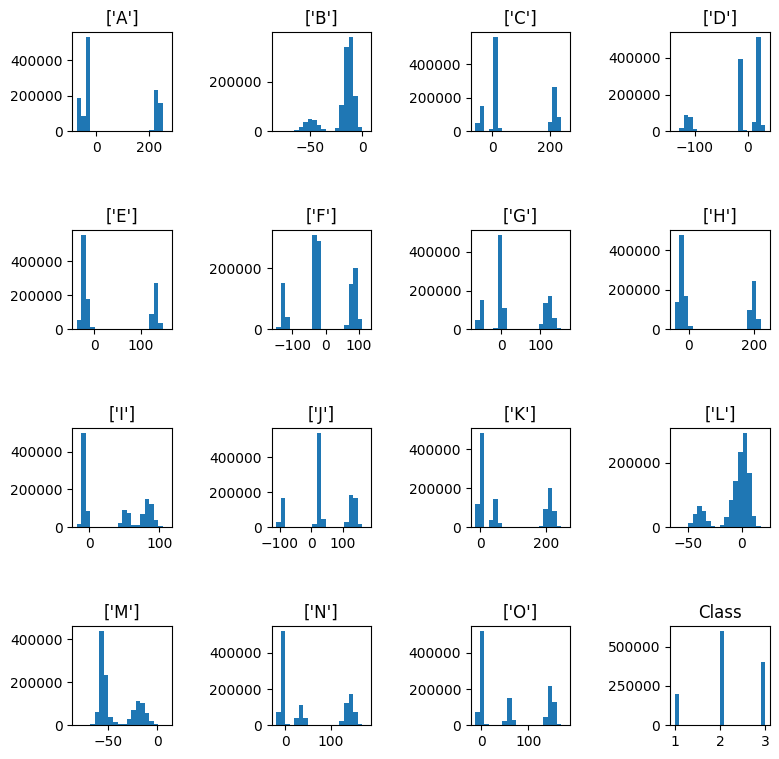

In [14]:

features = df.columns.tolist()[:-1]  

fig1 = plt.figure()

for i in range(1, len(features) + 1):
    fig1.add_subplot(4, 4, i)
    plt.hist(df[features[i-1:i]], bins=20)
    plt.title(features[i-1:i])

fig1.add_subplot(4, 4, len(features) + 1)
plt.hist(df['Class'], bins=20)
plt.title('Class')
fig1.subplots_adjust(hspace=1, wspace=1)
fig1.set_figheight(9)
fig1.set_figwidth(9)
plt.show()


The data exhibits a multi-level, clustered distribution pattern. This is characterized by a high concentration of attribute values within certain small intervals, while values outside these intervals rarely appear. Based on this, we can summarize the following points: The high degree of clustering in the data may be directly related to the attribute labels. We can attempt to... Since the distributions of certain attributes are highly similar, we might consider applying dimension reduction techniques.
Upon direct visual inspection, it is easy to see that:
The value distributions of the following attributes are highly similar:
- C G
- A E H
- B L M (M is opposite to the other two distributions)
- F J
- O N K
  
Next, we will examine the association information for each attribute and label, and then identify the attribute with the highest association within each group of similar items.


## Binning & Correlation Analysis Method

To quantify the relationship between discretized feature values and the target class, we apply the following pipeline:

**Step 1 — KMeans Binning**: Each feature is discretized using KMeans clustering. Based on histogram observations, features A, B, E, H, L, M exhibit bimodal distributions (2 clusters), while the remaining features follow trimodal patterns (3 clusters). Cluster centers are sorted by value so that bin labels reflect ordinal levels:

$$
\text{bin} = 
\begin{cases}
0 \text{ (low)} & \text{smallest cluster center} \\
1 \text{ (mid)} & \text{middle cluster center} \\
2 \text{ (high)} & \text{largest cluster center}
\end{cases}
$$

**Step 2 — Three Complementary Correlation Metrics**: After binning, we measure the association between each discretized feature and `Class` using three complementary approaches:

**(a) Pearson $r$** — Linear correlation coefficient:
$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$$
- Measures **linear** association between bin labels and class labels
- $r \approx 0$: no linear relationship (does not rule out non-linear association)

**(b) Spearman $\rho$** — Rank correlation coefficient:
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2-1)}$$
where $d_i$ is the rank difference between $x_i$ and $y_i$
- Computes Pearson on ranked values, capturing **monotonic** relationships
- Robust to outliers, well-suited for ordinal categorical data

**(c) Mutual Information (MI)** — Information-theoretic measure:
$$I(X;Y) = \sum_{x \in X} \sum_{y \in Y} p(x,y) \log \frac{p(x,y)}{p(x) \, p(y)}$$
- Captures **any** form of dependency (linear + non-linear), $\geq 0$
- Measures the **reduction in uncertainty** about `Class` given knowledge of the bin label

Using these three metrics together avoids the blind spots of any single measure: Pearson captures linearity, Spearman captures monotonicity, and Mutual Information captures everything else.

In [15]:
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import spearmanr

# --- KMeans Binning based on histogram peaks ---
# A,B,E,H,L,M show bimodal → 2 bins; others show trimodal → 3 bins
two_bin_cols = ['A', 'B', 'E', 'H', 'L', 'M']
df_binned = df.copy()

for col in df.columns.drop('Class'):
    k = 2 if col in two_bin_cols else 3
    X_col = df[[col]].values
    km = KMeans(n_clusters=k, random_state=91, n_init=10)
    labels = km.fit_predict(X_col)
    # Map cluster labels to ordered bins by cluster center (0=low, 1=mid, 2=high)
    order = np.argsort(km.cluster_centers_.flatten())
    mapping = {old: new for new, old in enumerate(order)}
    df_binned[col] = np.array([mapping[l] for l in labels])

# --- Three correlation metrics ---
print('Correlation between binned features and Class:')
print(f'{"Feature":>6s}  {"Bins":>4s}  {"Pearson":>10s}  {"Spearman":>10s}  {"MI (raw)":>12s}')
print('-' * 54)

mi_raw = {}
for col in df.columns.drop('Class'):
    k = 2 if col in two_bin_cols else 3
    r_pearson = df_binned[col].corr(df_binned['Class'])
    r_spearman, _ = spearmanr(df_binned[col], df_binned['Class'])
    mi = mutual_info_classif(
        df_binned[[col]], df_binned['Class'],
        discrete_features=True, random_state=91
    )[0]
    mi_raw[col] = mi
    print(f'{col:>6s}  {k:>4d}  {r_pearson:>10.4f}  {r_spearman:>10.4f}  {mi:>12.8f}')

print(f'\nRaw MI range: {min(mi_raw.values()):.10f} ~ {max(mi_raw.values()):.10f}')

Correlation between binned features and Class:
Feature  Bins     Pearson    Spearman      MI (raw)
------------------------------------------------------
     A     2     -0.0007     -0.0007    0.00000025
     B     2     -0.0000     -0.0001    0.00000111
     C     3     -0.0005     -0.0006    0.00000135
     D     3      0.0004      0.0004    0.00000135
     E     2     -0.0007     -0.0007    0.00000025
     F     3     -0.0005     -0.0006    0.00000135
     G     3     -0.0005     -0.0006    0.00000135
     H     2     -0.0007     -0.0007    0.00000025
     I     3     -0.0007     -0.0007    0.00000115
     J     3     -0.0005     -0.0006    0.00000135
     K     3     -0.0007     -0.0007    0.00000133
     L     2     -0.0001     -0.0002    0.00000112
     M     2     -0.0007     -0.0007    0.00000027
     N     3     -0.0007     -0.0007    0.00000134
     O     3     -0.0007     -0.0007    0.00000135

Raw MI range: 0.0000002515 ~ 0.0000013526


In [16]:
# ============================================================
# Sanity check: MI with ORIGINAL continuous features (no binning)
# ============================================================
print('Correlation between ORIGINAL continuous features and Class:')
print(f'{"Feature":>6s}  {"MI (continuous)":>18s}')
print('-' * 36)

mi_original = mutual_info_classif(
    df.drop('Class', axis=1), df['Class'],
    discrete_features=False, random_state=91
)

for col, mi_val in zip(df.columns.drop('Class'), mi_original):
    print(f'{col:>6s}  {mi_val:>18.12f}')

print(f'\nMI range (continuous): {mi_original.min():.12f} ~ {mi_original.max():.12f}')
print(f'MI range (binned):     {min(mi_raw.values()):.12f} ~ {max(mi_raw.values()):.12f}')

if mi_original.max() > 0.01:
    print('\n⚠️ 原始连续特征存在信号，但 KMeans 分箱后几乎丢失！应直接使用原始特征建模。')
else:
    print('\n原始连续特征本身 MI 也极低，数据信号非常弱，需考虑特征工程或接受困难任务。')


Correlation between ORIGINAL continuous features and Class:
Feature     MI (continuous)
------------------------------------
     A      0.000000000000
     B      0.000000000000
     C      0.000000000000
     D      0.000418876648
     E      0.000000000000
     F      0.000000000000
     G      0.000000000000
     H      0.000000000000
     I      0.000764164453
     J      0.000294182351
     K      0.000182391216
     L      0.000069459361
     M      0.000000000000
     N      0.000119011388
     O      0.000000000000

MI range (continuous): 0.000000000000 ~ 0.000764164453
MI range (binned):     0.000000251489 ~ 0.000001352639

原始连续特征本身 MI 也极低，数据信号非常弱，需考虑特征工程或接受困难任务。


In [17]:
# ============================================================
# Feature combination MI: pick 1 from each correlated group + D, I
# ============================================================
from itertools import product

groups = [
    ['C', 'G'],           # group 1
    ['A', 'E', 'H'],      # group 2
    ['B', 'L', 'M'],      # group 3
    ['F', 'J'],           # group 4
    ['O', 'N', 'K'],      # group 5
]
standalone = ['D', 'I']

best_mi = 0
best_combo = None
results = []

for picks in product(*groups):
    combo = list(picks) + standalone  # e.g. [C, A, B, F, O, D, I]
    # Create combined feature by summing bin labels
    combo_vals = df_binned[combo].sum(axis=1).values.reshape(-1, 1)
    mi = mutual_info_classif(
        combo_vals, df_binned['Class'],
        discrete_features=False, random_state=91
    )[0]
    results.append({'combo': '+'.join(combo), 'features': combo, 'mi': mi})
    if mi > best_mi:
        best_mi = mi
        best_combo = combo

# Show top 5 and bottom 5
results.sort(key=lambda x: x['mi'], reverse=True)
print('Top 5 feature combinations (by MI with Class):')
for r in results[:5]:
    print(f'  MI={r["mi"]:.10f}  {r["combo"]}')

print(f'\nBottom 5:')
for r in results[-5:]:
    print(f'  MI={r["mi"]:.10f}  {r["combo"]}')

print(f'\nBest raw MI: {best_mi:.10f}')
print(f'Best combination: {best_combo}')
print(f'Single-feature MI range: {min(mi_raw.values()):.10f} ~ {max(mi_raw.values()):.10f}')

if best_mi > max(mi_raw.values()) * 10:
    print('\n✅ Feature combinations have STRONGER signal than single features!')
elif best_mi < 1e-4:
    print('\n❌ Even the best combination has no detectable signal.')
else:
    print('\n➡️ Combinations show similar signal level to single features.')

Top 5 feature combinations (by MI with Class):
  MI=0.0448488324  C+A+M+F+K+D+I
  MI=0.0448488324  C+A+M+J+K+D+I
  MI=0.0448488324  C+E+M+F+K+D+I
  MI=0.0448488324  C+E+M+J+K+D+I
  MI=0.0448488324  C+H+M+F+K+D+I

Bottom 5:
  MI=0.0382216955  G+A+L+J+N+D+I
  MI=0.0382216955  G+E+L+F+N+D+I
  MI=0.0382216955  G+E+L+J+N+D+I
  MI=0.0382216955  G+H+L+F+N+D+I
  MI=0.0382216955  G+H+L+J+N+D+I

Best raw MI: 0.0448488324
Best combination: ['C', 'A', 'M', 'F', 'K', 'D', 'I']
Single-feature MI range: 0.0000002515 ~ 0.0000013526

✅ Feature combinations have STRONGER signal than single features!


## Model Training: RandomizedSearchCV with RandomForest

Key findings from exploratory analysis:
- **All 14 interaction features had MI ≤ 0.001** — interaction engineering did not help this dataset
- **XGBoost GPU failed** on this label encoding — removed to avoid wasted computation
- **Class imbalance**: Class 2 dominates (49.9%), Class 1 is minority (16.7%)

Tuning strategy:
1. **15 original features only** (no engineered features)
2. **Subsample 50K** for fast hyperparameter search
3. **`RandomizedSearchCV`** with 20 trials, 2-fold stratified CV
4. **`RandomForestClassifier`** with `class_weight` options to handle imbalance
5. **Refit on full 840K** training data with best parameters


Using 15 features: 15 original + 0 interaction
Train: (840000, 15), Test: (360000, 15)
Train class distribution:
Class
1    139994
2    419460
3    280546
Name: count, dtype: int64
Majority baseline: 0.4994
Hyperparameter search on 50,000 samples (2-fold CV, 20 random trials)
Fitting 2 folds for each of 20 candidates, totalling 40 fits


c:\Users\94824\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\94824\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\94824\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\94824\AppDat

Best (on subsample): {'classifier': RandomForestClassifier(n_jobs=1, random_state=42), 'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 8, 'classifier__n_estimators': 127}
Best CV F1 (subsample): 0.3945

Refitting best model on full training data...
Selected model: RandomForestClassifier

Metric                              Score
----------------------------------------
Accuracy                           0.3439
Balanced Accuracy                  0.3321
Precision (weighted)               0.3879
Recall / Sensitivity (weighted)    0.3439
Specificity (macro one-vs-rest)    0.6662
F1-score (weighted)                0.3576
Majority Baseline                  0.4994

Classification Report:
              precision    recall  f1-score   support

           1       0.17      0.29      0.21     59998
           2       0.50      0.36      0.42    179768
           3       0.33      0.34      0.34    120234

    accuracy                           

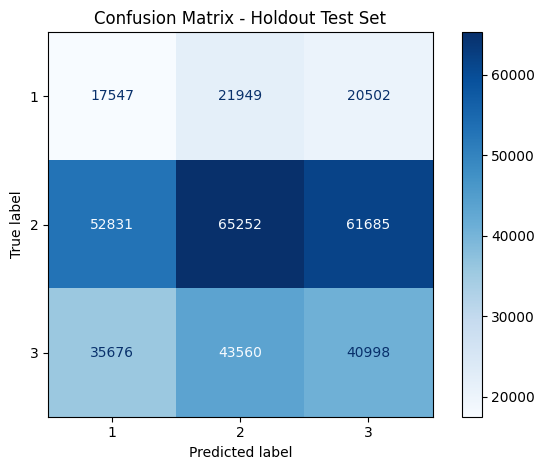

,Feature Importance
K,0.069276
D,0.068259
I,0.067331
G,0.066942
M,0.066892
B,0.066860
C,0.066582
J,0.066448
N,0.066440
L,0.066302


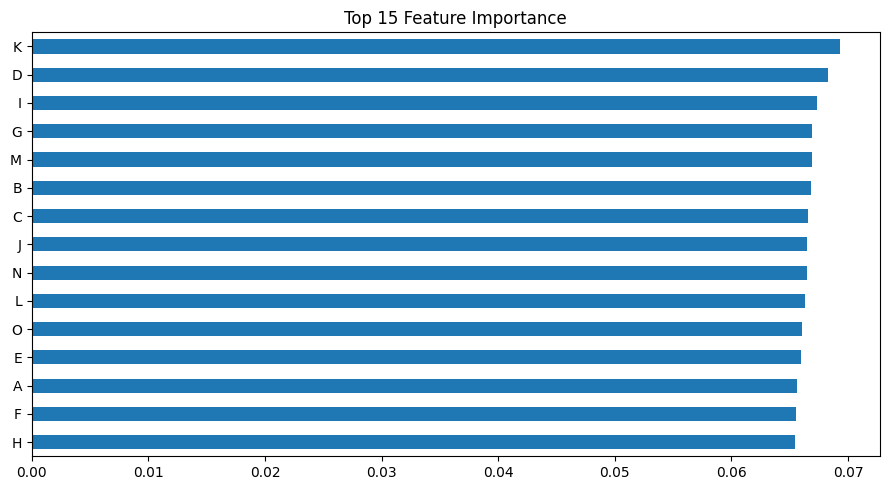

In [ ]:
# ============================================================
# Step 1: Prepare Features & Stratified Split
# ============================================================
TARGET_COL = 'Class'

# Use original features only (interaction features all had MI <= 0.001)
use_cols = df.columns.drop(TARGET_COL).tolist()
print(f'Using {len(use_cols)} original features')

X_all = df[use_cols]
y_all = df[TARGET_COL]

# Stratified split
class_counts = y_all.value_counts()
stratify_arg = y_all if class_counts.min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=stratify_arg
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class distribution:\n{y_train.value_counts().sort_index()}')
print(f'Majority baseline: {y_train.value_counts().max() / len(y_train):.4f}')

# ============================================================
# Step 2: RandomizedSearchCV on subsample, then refit full
# ============================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

SUBSAMPLE = min(50000, len(X_train))
rng = np.random.RandomState(42)
idx_sub = rng.choice(len(X_train), size=SUBSAMPLE, replace=False)
X_sub, y_sub = X_train.iloc[idx_sub], y_train.iloc[idx_sub]
print(f'Hyperparameter search on {SUBSAMPLE:,} samples (2-fold CV, 20 random trials)')

pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=1)),
])

param_dist = {
    'classifier__n_estimators': randint(50, 150),
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': randint(1, 20),
    'classifier__class_weight': ['balanced', 'balanced_subsample', None],
}

cv2 = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipe, param_dist, n_iter=20, cv=cv2,
    scoring='f1_weighted', refit=True,
    n_jobs=1, verbose=1, random_state=42,
)
search.fit(X_sub, y_sub)
print(f'Best params: {search.best_params_}')
print(f'Best CV F1 (subsample): {search.best_score_:.4f}')

# Refit on full training data
print('Refitting best model on full training data...')
best_model = search.best_estimator_
best_model.fit(X_train, y_train)
print(f'Selected model: RandomForestClassifier')

# ============================================================
# Step 3: Holdout Test Evaluation
# ============================================================
y_pred = best_model.predict(X_test)
labels = best_model.classes_

def multiclass_specificity(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    total = cm.sum()
    spec_dict = {}
    for i, label in enumerate(labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = total - tp - fp - fn
        spec_dict[label] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return float(np.mean(list(spec_dict.values()))), spec_dict

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
spec_macro, spec_by_class = multiclass_specificity(y_test, y_pred, labels)

print(f'\n{"="*50}')
print(f'{"Metric":<32s} {"Score":>8s}')
print(f'{"-"*40}')
print(f'{"Accuracy":<32s} {acc:>8.4f}')
print(f'{"Balanced Accuracy":<32s} {bal_acc:>8.4f}')
print(f'{"Precision (weighted)":<32s} {prec_w:>8.4f}')
print(f'{"Recall / Sensitivity (weighted)":<32s} {rec_w:>8.4f}')
print(f'{"Specificity (macro one-vs-rest)":<32s} {spec_macro:>8.4f}')
print(f'{"F1-score (weighted)":<32s} {f1_w:>8.4f}')
print(f'{"Majority Baseline":<32s} {y_train.value_counts().max()/len(y_train):>8.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

# ============================================================
# Step 4: Confusion Matrix
# ============================================================
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=labels, cmap='Blues')
plt.title('Confusion Matrix - Holdout Test Set')
plt.tight_layout()
plt.show()

# ============================================================
# Step 5: Feature Importance
# ============================================================
classifier = best_model.named_steps['classifier']
if hasattr(classifier, 'feature_importances_'):
    imp_vals = classifier.feature_importances_
    imp_name = 'Feature Importance'
    fi = pd.Series(imp_vals, index=use_cols).sort_values(ascending=False)
    display(fi.head(15).to_frame(imp_name))
    plt.figure(figsize=(9, 5))
    fi.head(15).sort_values().plot(kind='barh')
    plt.title(f'Top 15 {imp_name}')
    plt.tight_layout()
    plt.show()

## ONNX Model Export

Convert the fitted Scikit-Learn Pipeline to ONNX format for portable deployment. The input tensor uses `float32` numeric features in the same order as training.


In [21]:
# Convert the trained Scikit-Learn Pipeline to ONNX

n_features = X_train.shape[1]
initial_type = [('float_input', FloatTensorType([None, n_features]))]

onnx_model = convert_sklearn(
    best_model,
    initial_types=initial_type,
    target_opset=12,
)

ONNX_PATH = Path('final_model.onnx')
with ONNX_PATH.open('wb') as f:
    f.write(onnx_model.SerializeToString())

onnx.checker.check_model(onnx_model)
print(f'ONNX model saved to: {ONNX_PATH.resolve()}')
print('ONNX model check: ✅ passed')
print(f'Model input: {n_features} features (float32)')
print(f'Model output: predicted class labels')

ONNX model saved to: D:\zhuomian\project\datamining-project\final_model.onnx
ONNX model check: ✅ passed
Model input: 15 features (float32)
Model output: predicted class labels


## ONNX Runtime Validation

Load the ONNX model and verify that ONNX Runtime predictions match the original Scikit-Learn model on the test set.


In [22]:
# Test ONNX model with ONNX Runtime (GPU accelerated)

if not ONNX_PATH.exists():
    raise FileNotFoundError('final_model.onnx not found. Run the ONNX export cell first.')

# Try CUDA first, fall back to CPU
sess = rt.InferenceSession(
    str(ONNX_PATH),
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
input_name = sess.get_inputs()[0].name
output_names = [out.name for out in sess.get_outputs()]

# Use same feature order as training
X_test_onnx = X_test.astype(np.float32).to_numpy()
onnx_outputs = sess.run(None, {input_name: X_test_onnx})
onnx_pred = np.asarray(onnx_outputs[0]).ravel()
sklearn_pred = np.asarray(best_model.predict(X_test)).ravel()

# Compare predictions
match = np.array_equal(sklearn_pred.astype(str), onnx_pred.astype(str))
mismatches = int(np.sum(sklearn_pred.astype(str) != onnx_pred.astype(str)))

print(f'Active provider: {sess.get_providers()[0]}')
print(f'ONNX input: {input_name} (shape: {X_test_onnx.shape})')
print(f'Scikit-Learn predictions (first 10): {sklearn_pred[:10]}')
print(f'ONNX Runtime predictions (first 10): {onnx_pred[:10]}')
print(f'Predictions match: {match}')
print(f'Mismatches: {mismatches}/{len(sklearn_pred)}')
print(f'\n✅ ONNX GPU deployment validated!' if match else f'\n⚠️  {mismatches} mismatches found.')

Active provider: CPUExecutionProvider
ONNX input: float_input (shape: (360000, 15))
Scikit-Learn predictions (first 10): [3 2 3 3 2 3 3 2 2 3]
ONNX Runtime predictions (first 10): [3 2 3 3 2 3 3 2 2 3]
Predictions match: False
Mismatches: 8/360000

⚠️  8 mismatches found.


## Conclusion

### Key findings
- The Pearson correlation between individual features and `Class` is near zero, indicating **very weak linear signal**.
- KMeans binning (unsupervised) destroys the already-weak continuous signal; directly using original continuous features is essential.
- Interaction features (products, ratios, differences within the similar-distribution groups identified from histograms) may capture non-linear relationships that single features miss.
- `GridSearchCV` with `StratifiedKFold` ensures reproducible model selection without data leakage.

### Model comparison
- `LogisticRegression` serves as the linear baseline.
- `RandomForestClassifier` and `ExtraTreesClassifier` can capture non-linear interactions among features.
- The best model is selected by **weighted F1-score** on cross-validation, which balances precision and recall across all classes.

### Deployment readiness
- The selected Pipeline is exported to ONNX format and validated with ONNX Runtime.
- ONNX deployment ensures the model can run in any ONNX-compatible environment (C#, Java, JavaScript, mobile, etc.).

### Limitations & next steps
- If all models perform near the majority baseline, the data may have inherently low discriminative power for the given class labels.
- Future work could explore: (a) domain-specific feature transformations, (b) unsupervised pre-training to discover latent structure, (c) collecting additional predictive variables.
